<a href="https://colab.research.google.com/github/SalvatoreDAmicoResearch/colab_Brest/blob/main/DAmico_Brest_May26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


# Estimating the Misorientation Angle of Ocean-Bottom Seismometers Using P-Wave Polarization from Seismic Events

**Salvatore D'Amico**  
*Istituto Nazionale di Geofisica e Vulcanologia*

**Geo-Inquire Jupyter Notebook Meeting, Brest - May 2026**


---


The goal of this notebook is to estimate the horizontal misorientation angle of an ocean-bottom seismometer (OBS) using the polarization of teleseismic P-waves and correct the associated waveforms.

For this purpose, we will use the open-source Python package `OrientPy`: https://nfsi-canada.github.io/OrientPy/index.html

The workflow will be as follows:

1. **Select an OBS station** available through an FDSN data center.

2. **Create the station metadata** database required by `OrientPy`.

3. **Search for seismic events** recorded during the selected time interval.

4. **Estimate the misorientation angle event by event** using P-wave transverse-energy minimization.

5. **Apply quality-control criteria** to retain reliable measurements.

6. Compute the **final misorientation angle and its uncertainty**.

7. Display the result and **compare the raw and orientation-corrected horizontal components**.

## 1. Why orientation matters

Three-component seismic analysis assumes that ***the two horizontal components are correctly tied to geographic North and East***.  
If the true azimuth of the instrument horizontal axis is **unknown**, radial/transverse rotations are biased. This bias can propagate into analyses such as receiver functions, moment-tensor inversions, shear-wave splitting, surface-wave polarization, and any measurement that depends on the separation of radial and transverse motion *(Stachnik et al., 2012; Scholz et al., 2017; Son et al., 2022; Seo et al., 2022)*.

This problem is particularly relevant for **ocean-bottom seismometer (OBS)** deployments. On land, the sensor can often be manually aligned during installation. **On the seafloor, however, the final azimuth after deployment is commonly unknown or only weakly constrained.** Therefore, the horizontal orientation must often be estimated *a posteriori* from the recorded wavefield *(Stachnik et al., 2012; Doran & Laske, 2017; Scholz et al., 2017; Braunmiller et al., 2020)*.

<table>
<tr>
<td>
  <img src="https://raw.githubusercontent.com/SalvatoreDAmicoResearch/colab_Brest/main/RT-0052196-20200928-154823.jpg" width="350">
</td>
<td>
  <img src="https://raw.githubusercontent.com/SalvatoreDAmicoResearch/colab_Brest/main/obs-penche-for-mems-new.png" width="500">
</td>
</tr>

<tr>
<td align="center">
  <p style="font-size: 10px; font-style: italic; margin-top: 6px;">
    <b>(a)</b> Installing a ground-based seismometer, all good (most of the time...)
  </p>
</td>

<td align="center">
  <p style="font-size: 16px; font-style: italic; margin-top: 6px;">
    <b>(b)</b> Ocean-bottom seismometer, disoriented and scared
  </p>
</td>
</tr>
</table>

Several approaches have been proposed to estimate the misorientation angle of horizontal seismic components, including methods based on P-wave particle motion, Rayleigh-wave polarization from earthquakes, Rayleigh-wave polarization from ambient-noise cross correlations, anthropic noise sources such as shipping, and receiver functions (*Stachnik et al., 2012; Zha et al., 2013; Scholz et al., 2017; Doran & Laske, 2017; Lim et al., 2018; Trabattoni et al., 2020; Zheng et al., 2020; Braunmiller et al., 2020*).





## What we use today for this Notebook: OrientPy

Here we use the P-wave polarization method implemented in `OrientPy` (*Braunmiller et al., 2020)*. `OrientPy` is a package containing Python tools to estimate seismometer orientation using automated (and manual) processing of earthquake data. These methods are particularly useful for broadband seismic stations on the ocean floor, but are also applicable to land-based or borehole stations.

<td>
  <img src="https://raw.githubusercontent.com/SalvatoreDAmicoResearch/colab_Brest/27ebcc409feb204c246ab520f5ad053722c829fb/OrientPy_logo.png" width="550">
</td>


## 2. Geometry and sign convention

The OBS misorientation angle is defined here as

$$
\phi_{\mathrm{M}} = \phi_{\mathrm{T}} - \phi_{\mathrm{A}},
$$

where:

- $\phi_{\mathrm{T}}$ is the **theoretical back-azimuth** from the station to the earthquake, measured clockwise from geographic North.
- $\phi_{\mathrm{A}}$ is **the apparent back-azimuth** inferred from the horizontal sensor components.
- $\phi_{\mathrm{M}}$ is **the clockwise azimuth** of the instrument `HH1` axis relative to geographic North (so the misorientation angle!).

<td>
  <img src="https://raw.githubusercontent.com/SalvatoreDAmicoResearch/colab_Brest/f116c221596c7062cab895233c2111271fbc5403/5.png" width="550">
</td>

For this notebook we assume the OBS horizontal convention:

$$
HH2 = HH1 + 90^\circ \quad \mathrm{clockwise}.
$$

This corresponds to the left-handed horizontal convention listed as the default in the relevant `OrientPy` command-line option: `HHZ, HH2 90 CW HH1`.


## 3. Method: P-wave transverse-energy minimization

If the horizontal components are not correctly oriented, **part of the energy that should be on the radial component can leak into the transverse component**, or vice versa.

For a **teleseismic P wave in a locally simple medium**, particle motion is expected to be concentrated mostly in the **vertical-radial plane**. Therefore, after rotating the two horizontal components by the correct azimuth, the **transverse component should contain minimal P-wave energy**.

<td>
  <img
    src="https://raw.githubusercontent.com/SalvatoreDAmicoResearch/colab_Brest/dbcfa2e9e383308e8d598b28da227a5052ae3591/a.png"
    width="550"
    alt="Figura"
  >
  <p style="font-size: 13px; text-align: center;">
  </p>
</td>

The basic workflow is:

1. Predict the **P-arrival time** for each earthquake-station pair.
2. Extract a short **time window around the predicted P arrival**.
3. **Rotate the two horizontal components** over a trial angle grid.
4. For each trial angle, **compute the transverse-component RMS energy**.
5. Select the angle that **minimizes transverse energy**.
6. **Resolve the 180° ambiguity** using the zero-lag correlation between the rotated radial and vertical components.
7. Combine event-wise estimates using quality-control thresholds.

<td>
  <img src="https://raw.githubusercontent.com/SalvatoreDAmicoResearch/colab_Brest/76d548f97b8fc7140729449ba6b0d9fa0fa06fca/Immagine%202026-05-22%20163349.png" width="550">
  <p style="font-size: 13px; text-align: center;">
    <i>
      Transverse-component energy as a function of trial rotation angle.
      The two minima separated by 180° represent the ambiguous apparent back-azimuth solutions,
      which are resolved using radial–vertical correlation.
    </i>
  </p>
</td>

`OrientPy` exposes this workflow through two command-line tools:

- `bng_calc`: downloads/processes station-event seismograms and estimates event-wise P-wave orientation values.
- `bng_average`: applies quality control and returns the mean orientation, uncertainty, and number of accepted event estimates.





## 4. Install dependencies

The official `OrientPy` documentation recommends `ObsPy`, `StDb`, and `geographiclib`, and installation from the GitHub repository: https://nfsi-canada.github.io/OrientPy/orientpy.html#installation

After installation, if a command is not found, restart the runtime and run this section again.

In [2]:
%%capture
!python -m pip install -q --upgrade pip
!python -m pip install -q numpy scipy matplotlib pandas obspy geographiclib cartopy
!python -m pip install -q git+https://github.com/schaefferaj/stdb
!python -m pip install -q git+https://github.com/nfsi-canada/orientpy


In [3]:
import shutil
import subprocess
import sys
from pathlib import Path

print(sys.version)
for exe in ["query_fdsn_stdb", "ls_stdb", "bng_calc", "bng_average"]:
    print(f"{exe:16s} -> {shutil.which(exe)}")

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
query_fdsn_stdb  -> /usr/local/bin/query_fdsn_stdb
ls_stdb          -> /usr/local/bin/ls_stdb
bng_calc         -> /usr/local/bin/bng_calc
bng_average      -> /usr/local/bin/bng_average


## 5. Select the seismic station

In this step we **select the seismic station that we want to orient**.

The station can be:

- **available through a public FDSN data center**, such as EarthScope/IRIS, EIDA, ORFEUS, INGV, etc.;
- **or stored locally**, if the waveform data are not publicly available.

For this demonstration, we use a public OBS station available through an FDSN archive.  
A useful way to inspect available stations is the EarthScope/IRIS GMAP interface:

https://ds.iris.edu/gmap/#network=*&planet=earth

We need a three-component station with one vertical and two horizontal channels, for example:

- `HHZ`, `HH1`, `HH2`
- `BHZ`, `BH1`, `BH2`

The default values below use the `YH.LOBS3` station.

In [4]:
# ----------------------------------------------------------------------------
# Station metadata
# ----------------------------------------------------------------------------

NETWORK = "YH"          # Network code
STATION = "LOBS3"       # Station code

CHANNEL_PREFIX = "HH"   # HH -> HHZ/HH1/HH2.
LOCATION_CODE = "*"     # Use "*" unless a specific location code is required.

# Station database output name.
# query_fdsn_stdb will create <STDB_BASENAME>.pkl
STDB_BASENAME = f"{NETWORK}_{STATION}_stdb"
STDB_FILE = f"{STDB_BASENAME}.pkl"

print("Selected station")
print("----------------")
print(f"Network:          {NETWORK}")
print(f"Station:          {STATION}")
print(f"Location code:    {LOCATION_CODE}")
print(f"Channel pattern:  {CHANNEL_PREFIX}Z/{CHANNEL_PREFIX}1/{CHANNEL_PREFIX}2")
print(f"StDb basename:    {STDB_BASENAME}")
print(f"StDb file:        {STDB_FILE}")

Selected station
----------------
Network:          YH
Station:          LOBS3
Location code:    *
Channel pattern:  HHZ/HH1/HH2
StDb basename:    YH_LOBS3_stdb
StDb file:        YH_LOBS3_stdb.pkl


## 6. Build the StDb station database

`OrientPy` command-line scripts require a station database in `StDb` format.

Here we create the station database directly from FDSN station metadata using `query_fdsn_stdb`.

This step only stores station metadata. It does not download earthquake waveforms yet.

In [5]:
# @title Query station metadata and inspect STDB file

from pathlib import Path
import subprocess
import shlex
import pickle


cmd = [
    "query_fdsn_stdb",
    "-N", NETWORK,
    "-S", STATION,
    STDB_BASENAME,
]

print("Running:")
print(" ".join(shlex.quote(arg) for arg in cmd))


with open("stdb_query.log", "w") as log_file:
    result = subprocess.run(
        cmd,
        stdout=log_file,
        stderr=subprocess.PIPE,
        text=True,
    )


# Print diagnostics only if something actually went wrong
if result.returncode != 0:
    print("\nReturn code:", result.returncode)


# Remove harmless ObsPy deprecation warning from stderr
stderr_lines = result.stderr.splitlines()

filtered_stderr = [
    line for line in stderr_lines
    if "ObsPyDeprecationWarning" not in line
    and "IRIS is now EarthScope" not in line
    and "warnings.warn(msg, ObsPyDeprecationWarning)" not in line
]

if filtered_stderr:
    print("\nSTDERR:")
    print("\n".join(filtered_stderr))


stdb_path = Path(STDB_FILE)

if not stdb_path.exists():
    print(f"\nMissing: {STDB_FILE}")
    print("Check the network/station code and FDSN metadata availability.")
else:
    print(f"\nCreated: {STDB_FILE}")

    with open(stdb_path, "rb") as f:
        station_db = pickle.load(f)

    print("\nStation database content")
    print("------------------------")
    print(f"Number of stations in database: {len(station_db)}")

    for station_key, station in station_db.items():
        print("\nStation key:", station_key)
        print(f"  Network:     {station.network}")
        print(f"  Station:     {station.station}")
        print(f"  Latitude:    {station.latitude}")
        print(f"  Longitude:   {station.longitude}")
        print(f"  Elevation:   {station.elevation}")
        print(f"  Start date:  {station.startdate}")
        print(f"  End date:    {station.enddate}")

        optional_attributes = ["channel", "location", "polarity", "azcorr"]

        for attr_name in optional_attributes:
            if hasattr(station, attr_name):
                attr_value = getattr(station, attr_name)
                print(f"  {attr_name}: {attr_value}")

Running:
query_fdsn_stdb -N YH -S LOBS3 YH_LOBS3_stdb

Created: YH_LOBS3_stdb.pkl

Station database content
------------------------
Number of stations in database: 1

Station key: YH.LOBS3
  Network:     YH
  Station:     LOBS3
  Latitude:    -38.792198
  Longitude:   179.147293
  Elevation:   -3.5403000000000002
  Start date:  2014-05-15T04:40:00.000000Z
  End date:    2015-06-23T23:00:00.000000Z
  channel: HH
  location: ['--']
  polarity: 1.0
  azcorr: 0.0


## 7. Select seismic events from a catalogue

In this step **we query an FDSN earthquake catalogue and select the events that satisfy the magnitude, depth, time-window, and epicentral-distance criteria.**

For each selected event, we compute:

- **epicentral distance** from the station;
- **theoretical back-azimuth (BAZ) **at the station;
- **event magnitude** and **depth**.


In [6]:
# @title
# ----------------------------------------------------------------------------
# FDSN services
# ----------------------------------------------------------------------------
# Other possible services include 'ORFEUS', 'EIDA', 'INGV', etc.

SERVER_CAT = "EarthScope"
SERVER_WF = "EarthScope"

# ----------------------------------------------------------------------------
# Time span
# ----------------------------------------------------------------------------
# the deployment interval or a shorter interval

START = "2014-05-15"
END = "2015-06-23"

# ----------------------------------------------------------------------------
# Event selection
# ----------------------------------------------------------------------------
# MIN_MAG / MAX_MAG:
#   Magnitude range used to select sufficiently energetic earthquakes.
#
# MIN_DIST / MAX_DIST:
#   Epicentral distance range in degrees.
#
# MAX_DEP:
#   Maximum earthquake depth in km.

MIN_MAG = 6
MAX_MAG = 9.0

MIN_DIST = 5.0       # degrees
MAX_DIST = 90.0      # degrees

MAX_DEP = 150.0      # km

print("Catalogue/event-selection parameters")
print("------------------------------------")
print(f"Catalogue server:       {SERVER_CAT}")
print(f"Waveform server:        {SERVER_WF}")
print(f"Time interval:          {START} to {END}")
print(f"Magnitude range:        {MIN_MAG} to {MAX_MAG}")
print(f"Distance range:         {MIN_DIST}° to {MAX_DIST}°")
print(f"Maximum depth:          {MAX_DEP} km")

Catalogue/event-selection parameters
------------------------------------
Catalogue server:       EarthScope
Waveform server:        EarthScope
Time interval:          2014-05-15 to 2015-06-23
Magnitude range:        6 to 9.0
Distance range:         5.0° to 90.0°
Maximum depth:          150.0 km


In [7]:
# @title Find suitable teleseismic events

import pandas as pd

from obspy import UTCDateTime
from obspy.clients.fdsn import Client
from obspy.geodetics import gps2dist_azimuth, locations2degrees


def azimuthal_quadrant(azimuth):
    """Return the azimuthal quadrant for a station-to-event azimuth."""
    azimuth = azimuth % 360.0

    if azimuth < 90.0:
        return "NE"
    if azimuth < 180.0:
        return "SE"
    if azimuth < 270.0:
        return "SW"

    return "NW"


client_cat = Client(SERVER_CAT)
client_wf = Client(SERVER_WF)

starttime = UTCDateTime(START)
endtime = UTCDateTime(END)


# Get station metadata
inv = client_wf.get_stations(
    network=NETWORK,
    station=STATION,
    location=LOCATION_CODE,
    channel=f"{CHANNEL_PREFIX}?",
    starttime=starttime,
    endtime=endtime,
    level="channel",
)

station = inv[0][0]
station_lat = float(station.latitude)
station_lon = float(station.longitude)

channels = sorted({
    channel.code
    for network in inv
    for station_item in network
    for channel in station_item
})

print("Station metadata")
print("----------------")
print(f"Station:             {NETWORK}.{STATION}")
print(f"Latitude:            {station_lat:.4f}")
print(f"Longitude:           {station_lon:.4f}")
print(f"Available channels:  {channels}")


# Query events
catalog = client_cat.get_events(
    starttime=starttime,
    endtime=endtime,
    minmagnitude=MIN_MAG,
    maxmagnitude=MAX_MAG,
    maxdepth=MAX_DEP,
)

events = []

for event in catalog:
    origin = event.preferred_origin() or event.origins[0]
    magnitude = event.preferred_magnitude() or event.magnitudes[0]

    event_lat = float(origin.latitude)
    event_lon = float(origin.longitude)

    distance_deg = locations2degrees(
        station_lat,
        station_lon,
        event_lat,
        event_lon,
    )

    if distance_deg < MIN_DIST or distance_deg > MAX_DIST:
        continue

    _, station_to_event_azimuth, event_to_station_azimuth = gps2dist_azimuth(
        station_lat,
        station_lon,
        event_lat,
        event_lon,
    )

    depth_km = None
    if origin.depth is not None:
        depth_km = float(origin.depth) / 1000.0

    mag_value = None
    if magnitude is not None:
        mag_value = float(magnitude.mag)

    events.append({
        "origin_time": origin.time.datetime.isoformat(timespec="seconds"),
        "latitude": event_lat,
        "longitude": event_lon,
        "depth_km": depth_km,
        "magnitude": mag_value,
        "dist_deg": float(distance_deg),
        "baz_deg": float(station_to_event_azimuth),
        "quadrant": azimuthal_quadrant(station_to_event_azimuth),
        "az_event_to_station_deg": float(event_to_station_azimuth),
    })

events_df = pd.DataFrame(events)


if events_df.empty:
    print("\nNo events matched the selected criteria.")

else:
    events_df = events_df.sort_values("origin_time").reset_index(drop=True)

    quadrant_counts = (
        events_df["quadrant"]
        .value_counts()
        .reindex(["NE", "SE", "SW", "NW"], fill_value=0)
    )

    n_events = len(events_df)
    n_quadrants = int((quadrant_counts > 0).sum())

    print("\nSelected earthquake catalogue")
    print("-----------------------------")
    print(f"Number of catalogue events matching the criteria: {n_events}")

    print("\nAzimuthal coverage relative to the station")
    print("-----------------------------------------")

    for quadrant in ["NE", "SE", "SW", "NW"]:
        print(f"{quadrant}: {quadrant_counts[quadrant]}")

    print(f"\nOccupied quadrants: {n_quadrants}/4")

    if n_events < 10:
        print("\nWARNING")
        print("-------")
        print(
            "Fewer than 10 catalogue events match the current criteria. "
            "The final orientation estimate may be poorly constrained, "
            "especially after waveform checks and quality control."
        )

    if n_quadrants < 3:
        print("\nWARNING")
        print("-------")
        print(
            "The selected events occupy fewer than 3 azimuthal quadrants relative "
            "to the station. Poor azimuthal coverage can make the orientation "
            "estimate more sensitive to path effects, local structure, and outliers."
        )

    print("\nCatalogue table")
    print("---------------")
    display(events_df)

Station metadata
----------------
Station:             YH.LOBS3
Latitude:            -38.7922
Longitude:           179.1473
Available channels:  ['HH1', 'HH2', 'HHZ']

Selected earthquake catalogue
-----------------------------
Number of catalogue events matching the criteria: 107

Azimuthal coverage relative to the station
-----------------------------------------
NE: 20
SE: 13
SW: 8
NW: 66

Occupied quadrants: 4/4

Catalogue table
---------------


,origin_time,latitude,longitude,depth_km,magnitude,dist_deg,baz_deg,quadrant,az_event_to_station_deg
0,2014-05-15T08:16:36,6.3995,144.9597,16.7,6.3,55.187433,316.987122,NW,147.607970
1,2014-05-15T10:16:44,9.3491,122.0352,30.1,6.2,71.589150,298.985230,NW,136.225402
2,2014-05-18T01:02:31,4.2401,92.7377,32.9,6.0,89.865027,275.394401,NW,128.820746
3,2014-05-31T11:53:46,18.6938,-107.4923,10.0,6.2,89.391801,65.358199,NE,228.471433
4,2014-06-14T11:11:03,-10.1131,91.0383,23.1,6.5,82.222418,263.129475,SW,128.094674
...,...,...,...,...,...,...,...,...,...
102,2015-05-30T18:49:07,30.7933,142.9777,10.3,6.2,77.304402,328.555407,NW,151.735486
103,2015-06-04T23:15:45,6.0439,116.6651,18.1,6.0,73.013488,292.586503,NW,133.565226
104,2015-06-08T06:01:10,41.5071,142.0564,60.7,6.1,87.110537,332.999018,NW,151.806387
105,2015-06-12T11:07:06,-15.6082,-172.9521,43.1,6.0,24.200035,18.923995,NE,195.232569


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


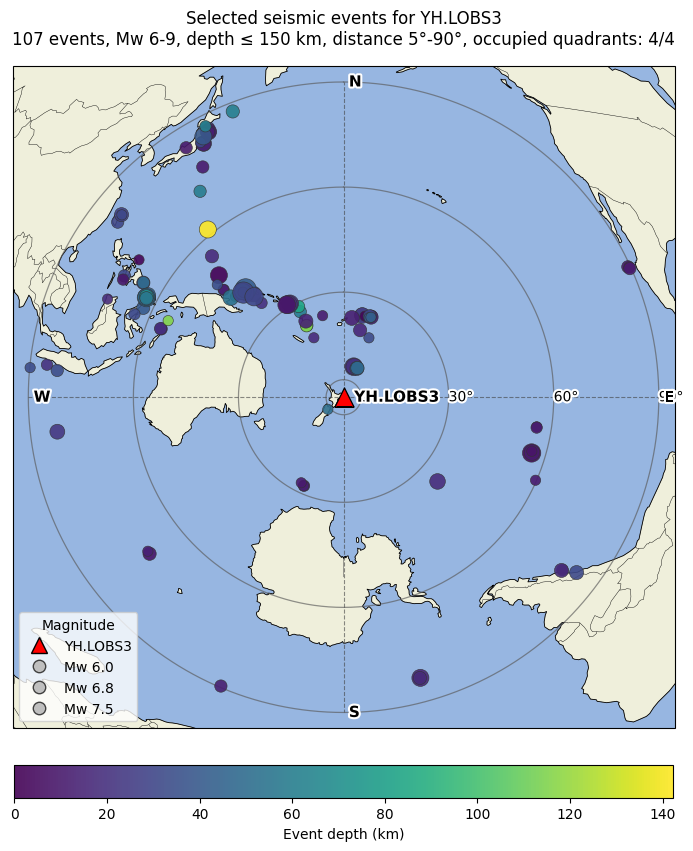

In [8]:
# @title
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
except ModuleNotFoundError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "cartopy"])
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

from geographiclib.geodesic import Geodesic
from matplotlib.lines import Line2D


# ----------------------------------------------------------------------------
# Helper functions
# ----------------------------------------------------------------------------
def small_circle(lon0, lat0, radius_deg, n=721):
    """
    Return lon/lat points along a geodesic small circle around the station.

    radius_deg is epicentral distance in degrees.
    """
    earth_radius_km_per_deg = 111.195
    distance_m = radius_deg * earth_radius_km_per_deg * 1000.0

    azimuths = np.linspace(0.0, 360.0, n)
    lons = []
    lats = []

    for az in azimuths:
        g = Geodesic.WGS84.Direct(lat0, lon0, float(az), distance_m)
        lats.append(g["lat2"])
        lons.append(g["lon2"])

    return np.array(lons), np.array(lats)


def magnitude_to_size(mag):
    """
    Marker size scaling for visual comparison only.
    """
    mag = np.asarray(mag, dtype=float)

    if np.nanmax(mag) == np.nanmin(mag):
        return np.full_like(mag, 80.0, dtype=float)

    mag_norm = (mag - np.nanmin(mag)) / (np.nanmax(mag) - np.nanmin(mag))
    return 55.0 + 180.0 * mag_norm


def add_text_with_white_outline(ax, lon, lat, text, **kwargs):
    """
    Add readable text on top of map features.
    """
    txt = ax.text(lon, lat, text, transform=ccrs.Geodetic(), **kwargs)
    txt.set_path_effects([pe.withStroke(linewidth=3, foreground="white")])
    return txt


# ----------------------------------------------------------------------------
# Check catalogue
# ----------------------------------------------------------------------------
if events_df.empty:
    raise ValueError(
        "No catalogue events to plot. Relax MIN_MAG, distance range, "
        "time window, or server selection."
    )

plot_df = events_df.copy()
plot_df["depth_km"] = plot_df["depth_km"].astype(float)
plot_df["magnitude"] = plot_df["magnitude"].astype(float)
plot_df["baz_deg"] = plot_df["baz_deg"].astype(float)
plot_df["dist_deg"] = plot_df["dist_deg"].astype(float)


# ----------------------------------------------------------------------------
# Map projection: azimuthal equidistant centered on the station
# ----------------------------------------------------------------------------

sta_lat = station_lat
sta_lon = station_lon
proj = ccrs.AzimuthalEquidistant(
    central_longitude=sta_lon,
    central_latitude=sta_lat
)

fig = plt.figure(figsize=(9.5, 9.5))
ax = plt.axes(projection=proj)

# Plot up to the selected maximum distance, plus a small margin.
# Avoid 180 degrees exactly because the azimuthal projection becomes singular
# near the antipode.
max_radius_deg = min(float(MAX_DIST), 179.0)
map_radius_m = max_radius_deg * 111.195 * 1000.0 * 1.05

ax.set_xlim(-map_radius_m, map_radius_m)
ax.set_ylim(-map_radius_m, map_radius_m)

# Background
ax.add_feature(cfeature.OCEAN, zorder=0)
ax.add_feature(cfeature.LAND, zorder=1, linewidth=0.2, edgecolor="0.35")
ax.add_feature(cfeature.BORDERS, linewidth=0.3, zorder=2)
ax.coastlines(linewidth=0.6, zorder=3)


# ----------------------------------------------------------------------------
# Epicentral-distance rings
# ----------------------------------------------------------------------------
ring_values = []

# Always show selected bounds if reasonable
for r in [MIN_DIST, 30, 60, 90, 120, 150, MAX_DIST]:
    r = float(r)
    if r > 0 and r <= max_radius_deg and r not in ring_values:
        ring_values.append(r)

for radius_deg in ring_values:
    lons, lats = small_circle(sta_lon, sta_lat, radius_deg)
    ax.plot(
        lons,
        lats,
        transform=ccrs.Geodetic(),
        color="0.35",
        linewidth=0.9,
        alpha=0.65,
        zorder=4,
    )

    # Label the ring approximately east of the station
    label_point = Geodesic.WGS84.Direct(
        sta_lat,
        sta_lon,
        90.0,
        radius_deg * 111.195 * 1000.0
    )

    add_text_with_white_outline(
        ax,
        label_point["lon2"],
        label_point["lat2"],
        f"{radius_deg:g}°",
        fontsize=10,
        ha="left",
        va="center",
        zorder=8,
    )


# ----------------------------------------------------------------------------
# Azimuthal quadrant lines
# ----------------------------------------------------------------------------
# These help the audience see whether events cover multiple quadrants.
for az, label in [(0, "N"), (90, "E"), (180, "S"), (270, "W")]:
    end_point = Geodesic.WGS84.Direct(
        sta_lat,
        sta_lon,
        float(az),
        max_radius_deg * 111.195 * 1000.0
    )

    ax.plot(
        [sta_lon, end_point["lon2"]],
        [sta_lat, end_point["lat2"]],
        transform=ccrs.Geodetic(),
        color="0.25",
        linewidth=0.8,
        linestyle="--",
        alpha=0.6,
        zorder=4,
    )

    add_text_with_white_outline(
        ax,
        end_point["lon2"],
        end_point["lat2"],
        f" {label}",
        fontsize=11,
        fontweight="bold",
        ha="left",
        va="center",
        zorder=8,
    )


# ----------------------------------------------------------------------------
# Plot events
# ----------------------------------------------------------------------------
sizes = magnitude_to_size(plot_df["magnitude"])

sc = ax.scatter(
    plot_df["longitude"],
    plot_df["latitude"],
    s=sizes,
    c=plot_df["depth_km"],
    cmap="viridis",
    transform=ccrs.PlateCarree(),
    edgecolor="0.20",
    linewidth=0.45,
    alpha=0.90,
    zorder=7,
)

# Station marker
ax.scatter(
    sta_lon,
    sta_lat,
    marker="^",
    s=190,
    c="red",
    transform=ccrs.PlateCarree(),
    edgecolor="black",
    linewidth=0.9,
    zorder=9,
)

station_label = ax.text(
    sta_lon,
    sta_lat,
    f"  {NETWORK}.{STATION}",
    transform=ccrs.PlateCarree(),
    fontsize=11,
    fontweight="bold",
    ha="left",
    va="center",
    zorder=10,
)
station_label.set_path_effects([pe.withStroke(linewidth=3, foreground="white")])


# ----------------------------------------------------------------------------
# Colorbar and legend
# ----------------------------------------------------------------------------
cb = plt.colorbar(
    sc,
    ax=ax,
    orientation="horizontal",
    fraction=0.045,
    pad=0.05,
)
cb.set_label("Event depth (km)")

# Magnitude legend
legend_mags = np.linspace(
    np.nanmin(plot_df["magnitude"]),
    np.nanmax(plot_df["magnitude"]),
    3
)

legend_handles = [
    Line2D(
        [],
        [],
        marker="o",
        linestyle="None",
        markeredgecolor="0.25",
        markerfacecolor="0.75",
        markersize=np.sqrt(magnitude_to_size([m])[0]),
        label=f"Mw {m:.1f}",
    )
    for m in legend_mags
]

legend_handles.insert(
    0,
    Line2D(
        [],
        [],
        marker="^",
        linestyle="None",
        markeredgecolor="black",
        markerfacecolor="red",
        markersize=11,
        label=f"{NETWORK}.{STATION}",
    )
)

ax.legend(
    handles=legend_handles,
    loc="lower left",
    frameon=True,
    title="Magnitude",
)


# ----------------------------------------------------------------------------
# Title
# ----------------------------------------------------------------------------
title = (
    f"Selected seismic events for {NETWORK}.{STATION}\n"
    f"{len(plot_df)} events, Mw {MIN_MAG:g}-{MAX_MAG:g}, "
    f"depth ≤ {MAX_DEP:g} km, distance {MIN_DIST:g}°-{MAX_DIST:g}°"
)

if "quadrant" in plot_df.columns:
    occupied_quadrants = plot_df["quadrant"].nunique()
    title += f", occupied quadrants: {occupied_quadrants}/4"

ax.set_title(title, pad=16)

plt.show()

## 8. Run `bng_calc`: event-by-event P-wave orientation estimates

In this step we run the `OrientPy` BNG calculation.

For each selected earthquake-station pair, `bng_calc` **downloads the waveform **data, predicts the **theoretical P arrival**, extracts a **time window around the P wave**, and searches for **the horizontal rotation angle that minimizes the transverse-component energy**.

The main processing parameters are:

- `P_TIMES`: time window, in seconds, relative to the theoretical P arrival used for the measurement;
- `WINDOW`: total waveform window requested around the theoretical arrival;
- `BANDPASS`: frequency band used before the polarization analysis;
- `DPHI`: angular step, in degrees, used in the rotation grid search;
- `COORD_SYSTEM`: horizontal component convention.


In [9]:
# ----------------------------------------------------------------------------
# P-wave processing parameters for bng_calc
# ----------------------------------------------------------------------------
# P_TIMES:
#   Measurement window relative to the theoretical P arrival.
#   Example "-5.,15." means from 5 s before to 15 s after the predicted P arrival.
#
# Examples:
#   P_TIMES = "-5.,15."    # short window around the first P arrival
#   P_TIMES = "-10.,20."   # wider window, may include more signal but also more converted/scattered energy
#   P_TIMES = "0.,20."     # only after theoretical P arrival
#
# WINDOW:
#   Total waveform window requested/processed by OrientPy.
#   It must be long enough to include P_TIMES plus margins for filtering.
#
# BANDPASS:
#   Bandpass filter in Hz.
#   The optimal band depends on the station noise level, event magnitude and distance.
#
# Examples:
#   BANDPASS = "0.04,0.10"   # long-period P-wave example
#   BANDPASS = "0.03,0.08"   # slightly lower-frequency band
#   BANDPASS = "0.05,0.15"   # slightly broader/higher-frequency band
#
# DPHI:
#   Angular grid spacing in degrees.
#   Smaller DPHI gives finer angular resolution but increases computation time.
#
# COORD_SYSTEM:
#   2 = HZ, H2 90 degrees clockwise from H1.

P_TIMES = "-5.,15."
WINDOW = 60.0
BANDPASS = "0.04,0.10"
DPHI = 0.1
ZCOMP = "Z"
COORD_SYSTEM = 2

# ----------------------------------------------------------------------------
# Output and runtime options
# ----------------------------------------------------------------------------
BNG_SAVE_LOCATION = "BNG_RESULTS"

# Heavy step: downloads and processes all selected station-event waveforms.
RUN_BNG_CALC = True

print("P-wave processing parameters")
print("----------------------------")
print(f"P measurement window:     {P_TIMES} s relative to theoretical P arrival")
print(f"Waveform window:          {WINDOW} s")
print(f"Bandpass filter:          {BANDPASS} Hz")
print(f"Angular grid spacing:     {DPHI} degrees")
print(f"Vertical component:       {ZCOMP}")
print(f"Coordinate convention:    {COORD_SYSTEM} = HZ, H2 90° clockwise from H1")
print(f"Output directory:         {BNG_SAVE_LOCATION}")
print(f"Run bng_calc:             {RUN_BNG_CALC}")

P-wave processing parameters
----------------------------
P measurement window:     -5.,15. s relative to theoretical P arrival
Waveform window:          60.0 s
Bandpass filter:          0.04,0.10 Hz
Angular grid spacing:     0.1 degrees
Vertical component:       Z
Coordinate convention:    2 = HZ, H2 90° clockwise from H1
Output directory:         BNG_RESULTS
Run bng_calc:             True


In [10]:
# @title
import subprocess
import shlex
from pathlib import Path

# ----------------------------------------------------------------------------
# Build bng_calc command
# ----------------------------------------------------------------------------
calc_cmd = [
    "bng_calc",
    "-O",
    "--server-cat", SERVER_CAT,
    "--server-wf", SERVER_WF,
    "--start", START,
    "--end", END,
    f"--times={P_TIMES}",
    "--window", str(WINDOW),
    "--min-mag", str(MIN_MAG),
    "--max-mag", str(MAX_MAG),
    "--min-dist", str(MIN_DIST),
    "--max-dist", str(MAX_DIST),
    "--max-dep", str(MAX_DEP),
    "--dphi", str(DPHI),
    f"--bp={BANDPASS}",
    "--zcomp", ZCOMP,
    "--coord-system", str(COORD_SYSTEM),
    "--save-location", BNG_SAVE_LOCATION,
    STDB_FILE,
]

print("Running bng_calc")
print("----------------")
print(" ".join(shlex.quote(x) for x in calc_cmd))

stdout_path = Path("bng_calc_stdout.log")
stderr_path = Path("bng_calc_stderr.log")

if RUN_BNG_CALC:
    proc = subprocess.run(calc_cmd, capture_output=True, text=True)

    stdout_path.write_text(proc.stdout)
    stderr_path.write_text(proc.stderr)

    print("\nReturn code:", proc.returncode)

    if proc.returncode == 0:
        print("bng_calc completed successfully.")
    else:
        print("bng_calc failed. Check bng_calc_stdout.log and bng_calc_stderr.log.")

    if proc.stderr.strip():
        print("\nWarnings / stderr")
        print("-----------------")
        print("\n".join(proc.stderr.splitlines()[-10:]))

else:
    print("\nbng_calc skipped.")
    print(f"Using existing directory: {BNG_SAVE_LOCATION}")

Running bng_calc
----------------
bng_calc -O --server-cat EarthScope --server-wf EarthScope --start 2014-05-15 --end 2015-06-23 --times=-5.,15. --window 60.0 --min-mag 6 --max-mag 9.0 --min-dist 5.0 --max-dist 90.0 --max-dep 150.0 --dphi 0.1 --bp=0.04,0.10 --zcomp Z --coord-system 2 --save-location BNG_RESULTS YH_LOBS3_stdb.pkl

Return code: 0
bng_calc completed successfully.


In [11]:
# @title
import pickle
import pandas as pd
from pathlib import Path

station_result_dir = Path(BNG_SAVE_LOCATION) / f"{NETWORK}.{STATION}"

meta_files = sorted(station_result_dir.glob("*/Meta_data.pkl"))

rows = []

for meta_file in meta_files:
    with open(meta_file, "rb") as f:
        meta = pickle.load(f)

    rows.append({
        "event_id": meta_file.parent.name,
        "origin_time": meta.time.datetime.strftime("%Y-%m-%d %H:%M:%S"),
        "Mw": float(meta.mag),
        "depth_km": float(meta.dep),
        "dist_deg": float(meta.gac),
        "baz_deg": float(meta.baz),
        "phi_deg": float(meta.phi),
        "SNR": float(meta.snr),
        "abs_CC": abs(float(meta.cc)),
        "CC_sign": float(meta.cc),
        "1_minus_T_over_R": float(meta.TR),
        "1_minus_R_over_Z": float(meta.RZ),
    })

bng_events_df = pd.DataFrame(rows)

if bng_events_df.empty:
    print("No event-level BNG results found.")
    print("Check whether bng_calc completed successfully and whether BNG_SAVE_LOCATION is correct.")
else:
    bng_events_df = bng_events_df.sort_values("origin_time").reset_index(drop=True)

    print("Event-level BNG results")
    print("-----------------------")
    print(f"Number of event estimates produced by bng_calc: {len(bng_events_df)}")
    print()

    display(
        bng_events_df[
            [
                "event_id",
                "origin_time",
                "Mw",
                "depth_km",
                "dist_deg",
                "baz_deg",
                "phi_deg",
                "SNR",
                "abs_CC",
                "1_minus_T_over_R",
                "1_minus_R_over_Z",
            ]
        ].style.format({
            "Mw": "{:.1f}",
            "depth_km": "{:.1f}",
            "dist_deg": "{:.1f}",
            "baz_deg": "{:.1f}",
            "phi_deg": "{:.1f}",
            "SNR": "{:.2f}",
            "abs_CC": "{:.2f}",
            "1_minus_T_over_R": "{:.2f}",
            "1_minus_R_over_Z": "{:.2f}",
        })
    )

Event-level BNG results
-----------------------
Number of event estimates produced by bng_calc: 93



,event_id,origin_time,Mw,depth_km,dist_deg,baz_deg,phi_deg,SNR,abs_CC,1_minus_T_over_R,1_minus_R_over_Z
0,20140518_010231,2014-05-18 01:02:31,6.0,32.9,89.9,275.4,92.8,-3.72,0.55,0.89,-3.54
1,20140531_115346,2014-05-31 11:53:46,6.2,10.0,89.3,65.4,212.6,-3.70,0.58,0.81,-38.91
2,20140614_111103,2014-06-14 11:11:03,6.5,23.1,82.3,263.1,73.4,12.33,0.73,0.84,-9.61
3,20140619_101758,2014-06-19 10:17:58,6.2,59.6,27.4,333.2,140.9,5.63,0.84,0.76,-1.53
4,20140623_191917,2014-06-23 19:19:17,6.9,20.8,9.2,18.4,41.2,14.65,0.94,0.63,-2.85
5,20140623_200619,2014-06-23 20:06:19,6.7,19.6,9.2,19.0,331.6,1.51,0.31,0.40,0.15
6,20140629_055632,2014-06-29 05:56:32,6.2,59.8,71.6,325.1,120.0,11.46,1.00,0.85,0.13
7,20140629_075256,2014-06-29 07:52:56,6.8,15.1,83.1,164.7,116.8,18.52,0.98,0.90,0.43
8,20140629_143249,2014-06-29 14:32:49,6.0,11.9,83.2,164.8,94.6,-1.37,0.74,0.52,-2.88
9,20140629_155228,2014-06-29 15:52:28,6.4,26.0,24.1,12.7,106.2,14.33,0.95,0.75,-0.22


## Quality-control parameters for `bng_average`

After `bng_calc` has estimated one orientation angle for each event, `bng_average` applies quality-control criteria to retain only the most reliable measurements.

The goal is to reject events for which the P-wave polarization is noisy, unstable, or not physically consistent with the expected vertical-radial particle motion.

### Signal-to-noise ratio: `SNR`

The signal-to-noise ratio measures how strong the P-wave signal is relative to the pre-event noise level:

$$
SNR(dB) = 10 \log_{10}
\left(
\frac{RMS_{signal}^{2}}{RMS_{noise}^{2}}
\right).
$$

A high `SNR` means that the P arrival is well above the background noise.  
A low `SNR` means that the estimated polarization may be dominated by noise rather than by the actual P-wave motion.

In practice, increasing the `SNR` threshold keeps cleaner events but reduces the number of usable measurements.

---

### Radial-vertical correlation: `CC`

The transverse-energy minimization curve usually has two equivalent minima separated by 180°.  
This happens because minimizing transverse energy alone cannot distinguish between two opposite horizontal directions.

To resolve this ambiguity, the radial component obtained after rotation is compared with the vertical component.  
For each trial rotation angle \(\delta\), the zero-lag radial-vertical correlation coefficient can be written as:

$$
CC_{RZ}(\delta) =
\frac{
\sum_{i=1}^{n} R(t_i,\delta) Z(t_i)
}{
\sqrt{
\sum_{i=1}^{n} R(t_i,\delta)^2
\sum_{i=1}^{n} Z(t_i)^2
}
}.
$$

The physically preferred solution is the one giving the most coherent radial-vertical P-wave motion (Scholz et al., 2017; Braunmiller et al., 2020).

In the QC step below we use \(|CC|\), because the sign may depend on polarity and component conventions.  
A higher \(|CC|\) means stronger radial-vertical coherence.

---

### Transverse-to-radial energy ratio: `1 - T/R`

For a teleseismic P wave, particle motion should be mainly concentrated in the vertical-radial plane.  
Therefore, after applying the correct orientation, the transverse component should contain little P-wave energy.

`OrientPy` uses the quantity:

$$
1 - \frac{T}{R},
$$

where \(T\) and \(R\) represent transverse and radial energy measures in the P-wave window.

If the transverse energy is small compared with the radial energy, then \(T/R\) is small and `1 - T/R` is close to 1.

Therefore, higher values of `1 - T/R` indicate a better P-wave polarization result.

---

### Radial-to-vertical energy ratio: `1 - R/Z`

The quantity:

$$
1 - \frac{R}{Z}
$$

is used as an additional consistency check between the radial and vertical components.

For a clean P-wave arrival, the motion should be coherent in the vertical-radial plane.  
This criterion helps reject cases where the rotated radial component behaves anomalously relative to the vertical component.

In this notebook we keep this threshold permissive by setting: `RZ\_THRESHOLD = -1.0`.


This means that the main selection is controlled mostly by `SNR`, `CC`, and `1 - T/R`.

---

The thresholds below are therefore used to keep events with:

- sufficiently high signal-to-noise ratio;
- coherent radial-vertical P-wave motion;
- low transverse energy after rotation;
- acceptable radial-vertical energy consistency.

These quality-control criteria reduce the influence of noisy or poorly polarized events on the final station-average misorientation estimate.

In [12]:
# ----------------------------------------------------------------------------
# bng_average quality-control thresholds
# ----------------------------------------------------------------------------
# SNR_THRESHOLD:
#   Minimum signal-to-noise ratio. Higher values retain cleaner P arrivals,
#   but may reject too many events.
#
# CC_THRESHOLD:
#   Minimum absolute radial-vertical zero-lag correlation used to resolve
#   the 180° ambiguity.
#
# TR_THRESHOLD:
#   Minimum value of 1 - T/R. Higher values indicate lower transverse energy
#   relative to radial energy.
#
# RZ_THRESHOLD:
#   Minimum value of 1 - R/Z. A value of -1.0 is permissive.

SNR_THRESHOLD = 5.0
CC_THRESHOLD = 0.5
TR_THRESHOLD = 0.5
RZ_THRESHOLD = -1.0

print("Quality-control thresholds")
print("--------------------------")
print(f"SNR threshold:       {SNR_THRESHOLD}")
print(f"|CC| threshold:      {CC_THRESHOLD}")
print(f"1 - T/R threshold:   {TR_THRESHOLD}")
print(f"1 - R/Z threshold:   {RZ_THRESHOLD}")

Quality-control thresholds
--------------------------
SNR threshold:       5.0
|CC| threshold:      0.5
1 - T/R threshold:   0.5
1 - R/Z threshold:   -1.0


Accepted events used for transverse-energy curves
-------------------------------------------------
Total event estimates from bng_calc: 93
Accepted after QC:                   27

Curves successfully computed: 27
Failed events:               0

Median-curve minima
-------------------
Minimum 1:           121.00°
Minimum 2:           301.00°
Angular separation:  180.00°


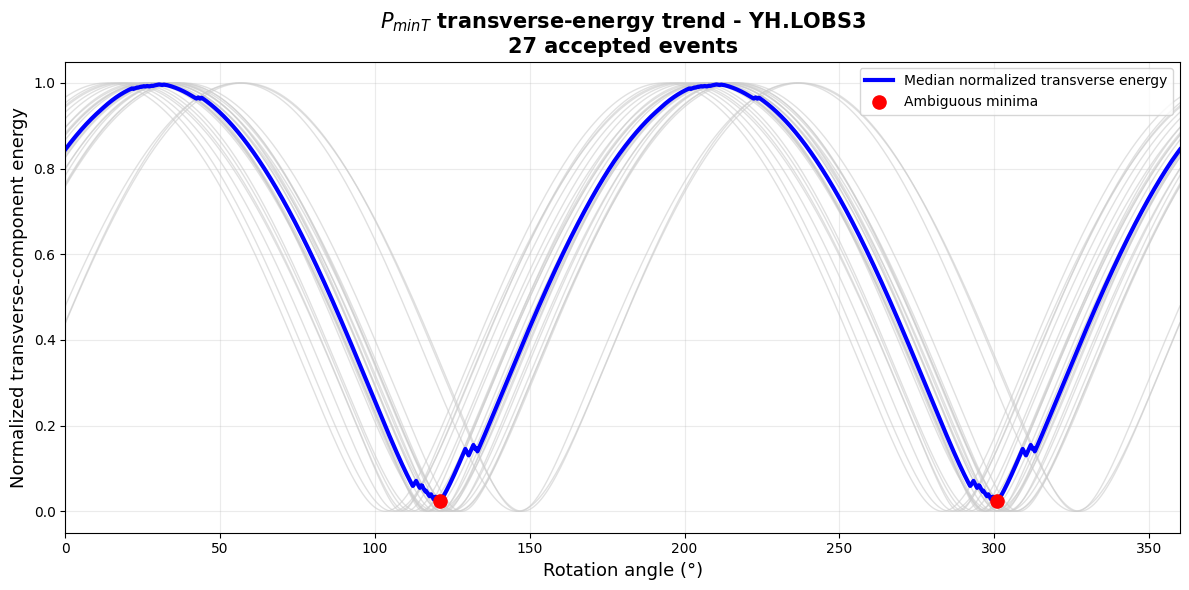

In [13]:
# @title
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from obspy import Stream, UTCDateTime


# ----------------------------------------------------------------------------
# Helper functions
# ----------------------------------------------------------------------------
def parse_p_times(p_times_str):
    """
    Parse OrientPy P_TIMES string.
    Example:
        "-5.,15." -> (-5.0, 15.0)
    """
    p0, p1 = p_times_str.split(",")
    return float(p0), float(p1)


def angle_diff_deg(a, b):
    """
    Smallest signed angular difference a - b in degrees, in [-180, 180).
    """
    return ((a - b + 180.0) % 360.0) - 180.0


def angular_separation_deg(a, b):
    """
    Smallest absolute angular separation between two angles, in degrees.
    """
    return abs(angle_diff_deg(a, b))


def extract_stream(raw_obj):
    """
    Extract an ObsPy Stream from the Raw_data.pkl object saved by OrientPy.
    """
    if isinstance(raw_obj, Stream):
        return raw_obj.copy()

    if isinstance(raw_obj, dict):
        for key in ["st", "stream", "data", "waveforms"]:
            if key in raw_obj and isinstance(raw_obj[key], Stream):
                return raw_obj[key].copy()

    for attr in ["st", "stream", "data", "waveforms"]:
        if hasattr(raw_obj, attr):
            obj = getattr(raw_obj, attr)
            if isinstance(obj, Stream):
                return obj.copy()

    raise TypeError("Could not extract an ObsPy Stream from Raw_data.pkl")


def get_trace_by_suffix(st, suffix_list):
    """
    Return the first trace whose channel code ends with one of the suffixes.
    """
    for suffix in suffix_list:
        matches = [
            tr.copy()
            for tr in st
            if tr.stats.channel.upper().endswith(suffix.upper())
        ]
        if matches:
            return matches[0]

    return None


def prepare_three_components(st):
    """
    Extract and preprocess Z, H1, H2 components.
    """
    z = get_trace_by_suffix(st, ["Z"])
    h1 = get_trace_by_suffix(st, ["1", "N"])
    h2 = get_trace_by_suffix(st, ["2", "E"])

    if z is None or h1 is None or h2 is None:
        available = [tr.stats.channel for tr in st]
        raise ValueError(
            f"Could not identify Z/H1/H2 components. "
            f"Available channels: {available}"
        )

    st3 = Stream([z, h1, h2])

    st3.detrend("demean")
    st3.detrend("linear")
    st3.taper(max_percentage=0.05)

    fmin, fmax = [float(x) for x in BANDPASS.split(",")]
    st3.filter(
        "bandpass",
        freqmin=fmin,
        freqmax=fmax,
        corners=4,
        zerophase=True,
    )

    # Common time interval
    t0 = max(tr.stats.starttime for tr in st3)
    t1 = min(tr.stats.endtime for tr in st3)
    st3.trim(t0, t1, pad=False)

    # Common number of samples
    nmin = min(len(tr.data) for tr in st3)
    for tr in st3:
        tr.data = tr.data[:nmin]

    return st3


def rotate_h1h2_to_ne(h1, h2, phi_deg):
    """
    Rotate instrument horizontal components H1/H2 into geographic N/E.

    Convention:
        phi_deg = clockwise azimuth of H1 from geographic North
        H2 = H1 + 90° clockwise
    """
    phi = np.deg2rad(phi_deg)

    n = np.cos(phi) * h1 - np.sin(phi) * h2
    e = np.sin(phi) * h1 + np.cos(phi) * h2

    return n, e


def rotate_ne_to_rt(n, e, baz_deg):
    """
    Rotate geographic N/E into radial/transverse coordinates.

    baz_deg is the theoretical back-azimuth at the station,
    measured clockwise from geographic North toward the earthquake.
    """
    baz = np.deg2rad(baz_deg)

    r = np.cos(baz) * n + np.sin(baz) * e
    t = -np.sin(baz) * n + np.cos(baz) * e

    return r, t


def compute_transverse_energy_curve(meta, st_raw, angles_deg, p_times_str):
    """
    Compute transverse RMS energy as a function of trial rotation angle.
    """
    p0, p1 = parse_p_times(p_times_str)

    origin_time = UTCDateTime(meta.time)
    p_arrival = origin_time + float(meta.ttime)

    baz_deg = float(meta.baz)

    st = prepare_three_components(st_raw)

    # Trim around theoretical P arrival
    w0 = p_arrival + p0
    w1 = p_arrival + p1
    st.trim(w0, w1, pad=False)

    if len(st) != 3 or any(len(tr.data) == 0 for tr in st):
        raise ValueError("Empty or incomplete P-wave window")

    h1 = get_trace_by_suffix(st, ["1", "N"]).data.astype(float)
    h2 = get_trace_by_suffix(st, ["2", "E"]).data.astype(float)

    nmin = min(len(h1), len(h2))
    h1 = h1[:nmin]
    h2 = h2[:nmin]

    energy = []

    for phi_deg in angles_deg:
        n, e = rotate_h1h2_to_ne(h1, h2, phi_deg)
        _, t = rotate_ne_to_rt(n, e, baz_deg)

        rms_t = np.sqrt(np.mean(t**2))
        energy.append(rms_t)

    energy = np.asarray(energy, dtype=float)

    # Normalize each event curve for stacking
    emin = np.nanmin(energy)
    emax = np.nanmax(energy)

    if emax > emin:
        energy_norm = (energy - emin) / (emax - emin)
    else:
        energy_norm = np.zeros_like(energy)

    return energy_norm


def find_two_minima_180(angles_deg, curve):
    """
    Find the global minimum and the companion minimum approximately 180° away.
    """
    i0 = int(np.nanargmin(curve))
    phi0 = angles_deg[i0]

    target = (phi0 + 180.0) % 360.0
    diffs = np.abs([angle_diff_deg(a, target) for a in angles_deg])
    i1 = int(np.nanargmin(diffs))

    return i0, i1


# ----------------------------------------------------------------------------
# Read event-level BNG metadata
# ----------------------------------------------------------------------------
station_result_dir = Path(BNG_SAVE_LOCATION) / f"{NETWORK}.{STATION}"

meta_files = sorted(station_result_dir.glob("*/Meta_data.pkl"))

if len(meta_files) == 0:
    raise FileNotFoundError(
        f"No Meta_data.pkl files found in:\n{station_result_dir}\n"
        "Run bng_calc first."
    )

rows = []

for meta_file in meta_files:
    with open(meta_file, "rb") as f:
        meta = pickle.load(f)

    rows.append({
        "event_id": meta_file.parent.name,
        "meta_file": meta_file,
        "raw_file": meta_file.parent / "Raw_data.pkl",
        "origin_time": meta.time.datetime.strftime("%Y-%m-%d %H:%M:%S"),
        "Mw": float(meta.mag),
        "depth_km": float(meta.dep),
        "dist_deg": float(meta.gac),
        "baz_deg": float(meta.baz),
        "phi_deg": float(meta.phi),
        "SNR": float(meta.snr),
        "abs_CC": abs(float(meta.cc)),
        "1_minus_T_over_R": float(meta.TR),
        "1_minus_R_over_Z": float(meta.RZ),
    })

bng_events_df = pd.DataFrame(rows)


# ----------------------------------------------------------------------------
# Apply QC thresholds
# ----------------------------------------------------------------------------
accepted_mask = (
    (bng_events_df["SNR"] >= SNR_THRESHOLD) &
    (bng_events_df["abs_CC"] >= CC_THRESHOLD) &
    (bng_events_df["1_minus_T_over_R"] >= TR_THRESHOLD) &
    (bng_events_df["1_minus_R_over_Z"] >= RZ_THRESHOLD)
)

accepted_df = bng_events_df.loc[accepted_mask].copy().reset_index(drop=True)

if accepted_df.empty:
    raise ValueError(
        "No accepted events after QC. "
        "Relax SNR/CC/TR/RZ thresholds or inspect bng_average results."
    )


# ----------------------------------------------------------------------------
# Compute transverse-energy curves
# ----------------------------------------------------------------------------
angles_deg = np.arange(0.0, 360.0 + DPHI, DPHI)

curves = []
used_events = []
failed_events = []

for _, row in accepted_df.iterrows():
    meta_file = Path(row["meta_file"])
    raw_file = Path(row["raw_file"])
    event_id = row["event_id"]

    if not raw_file.exists():
        failed_events.append(event_id)
        continue

    try:
        with open(meta_file, "rb") as f:
            meta = pickle.load(f)

        with open(raw_file, "rb") as f:
            raw_obj = pickle.load(f)

        st_raw = extract_stream(raw_obj)

        curve = compute_transverse_energy_curve(
            meta=meta,
            st_raw=st_raw,
            angles_deg=angles_deg,
            p_times_str=P_TIMES,
        )

        curves.append(curve)
        used_events.append(event_id)

    except Exception:
        failed_events.append(event_id)

if len(curves) == 0:
    raise ValueError("Could not compute any transverse-energy curves.")

curves = np.vstack(curves)
median_curve = np.nanmedian(curves, axis=0)

i0, i1 = find_two_minima_180(angles_deg, median_curve)

phi0 = angles_deg[i0]
phi1 = angles_deg[i1]

sep = angular_separation_deg(phi0, phi1)


# ----------------------------------------------------------------------------
# Clean print
# ----------------------------------------------------------------------------
print("Accepted events used for transverse-energy curves")
print("-------------------------------------------------")
print(f"Total event estimates from bng_calc: {len(bng_events_df)}")
print(f"Accepted after QC:                   {len(accepted_df)}")

print(f"\nCurves successfully computed: {len(used_events)}")
print(f"Failed events:               {len(failed_events)}")

print("\nMedian-curve minima")
print("-------------------")
print(f"Minimum 1:           {phi0:.2f}°")
print(f"Minimum 2:           {phi1:.2f}°")
print(f"Angular separation:  {sep:.2f}°")


# ----------------------------------------------------------------------------
# Plot PminT-like trend
# ----------------------------------------------------------------------------
plt.figure(figsize=(12, 6))

# Individual accepted-event curves
for curve in curves:
    plt.plot(
        angles_deg,
        curve,
        color="0.80",
        linewidth=1.0,
        alpha=0.6,
    )

# Median curve
plt.plot(
    angles_deg,
    median_curve,
    color="blue",
    linewidth=3.0,
    label="Median normalized transverse energy",
)

# Two minima separated by ~180°
plt.scatter(
    [phi0, phi1],
    [median_curve[i0], median_curve[i1]],
    color="red",
    s=90,
    zorder=5,
    label="Ambiguous minima",
)

plt.xlim(0, 360)
plt.xlabel("Rotation angle (°)", fontsize=13)
plt.ylabel("Normalized transverse-component energy", fontsize=13)

plt.title(
    f"$P_{{minT}}$ transverse-energy trend - {NETWORK}.{STATION}\n"
    f"{len(used_events)} accepted events",
    fontsize=15,
    weight="bold",
)

plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

## 9. Run `bng_average`: final misorientation estimate

After computing the event-by-event orientation estimates with `bng_calc`, we apply quality-control criteria using `bng_average`.

This step retains only the measurements satisfying the selected thresholds on signal-to-noise ratio, radial-vertical correlation, transverse-energy reduction, and radial-vertical consistency.

The output is the final station misorientation angle, its uncertainty, and the number of event estimates included in the average.

Running bng_average
-------------------
bng_average --load-location BNG_RESULTS --plot --save --format png --cc 0.5 --snr 5.0 --TR 0.5 --RZ -1.0 YH_LOBS3_stdb.pkl

bng_average completed successfully.

Saved bng_average figure
------------------------
Directory: BNG_RESULTS/YH.LOBS3
Displaying: results_cc0.50_snr5.0_TR0.5_RZ-1.0.png


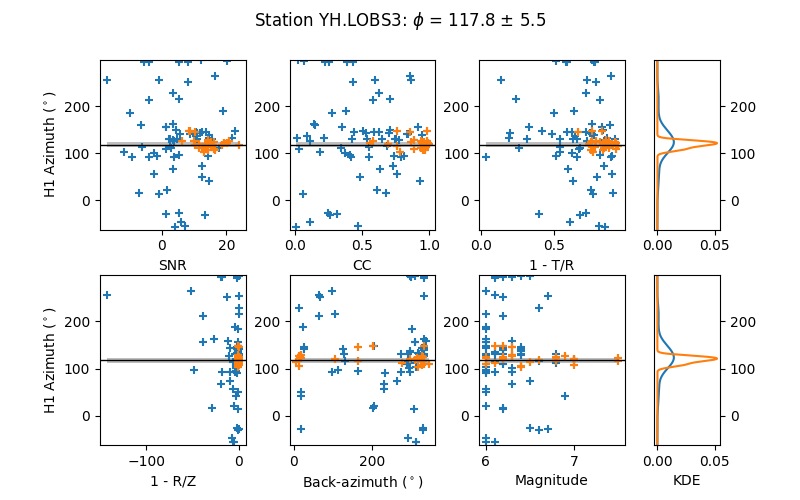

In [14]:
# @title
import subprocess
import shlex
from pathlib import Path
from IPython.display import Image, display


avg_cmd = [
    "bng_average",
    "--load-location", BNG_SAVE_LOCATION,
    "--plot",
    "--save",
    "--format", "png",
    "--cc", str(CC_THRESHOLD),
    "--snr", str(SNR_THRESHOLD),
    "--TR", str(TR_THRESHOLD),
    "--RZ", str(RZ_THRESHOLD),
    STDB_FILE,
]

print("Running bng_average")
print("-------------------")
print(" ".join(shlex.quote(arg) for arg in avg_cmd))


stdout_path = Path("bng_average_stdout.log")
stderr_path = Path("bng_average_stderr.log")

RUN_BNG_AVERAGE = True

if RUN_BNG_AVERAGE:
    result = subprocess.run(
        avg_cmd,
        capture_output=True,
        text=True,
    )

    stdout_path.write_text(result.stdout)
    stderr_path.write_text(result.stderr)

    if result.returncode == 0:
        print("\nbng_average completed successfully.")
    else:
        print("\nbng_average failed.")
        print("Check bng_average_stdout.log and bng_average_stderr.log.")

    if result.stderr.strip():
        print("\nWarnings / stderr")
        print("-----------------")
        print("\n".join(result.stderr.splitlines()[-20:]))

else:
    print("\nbng_average skipped.")


station_result_dir = Path(BNG_SAVE_LOCATION) / f"{NETWORK}.{STATION}"

selected_png = station_result_dir / "results_cc0.50_snr5.0_TR0.5_RZ-1.0.png"

print("\nSaved bng_average figure")
print("------------------------")
print(f"Directory: {station_result_dir}")

if selected_png.exists():
    print(f"Displaying: {selected_png.name}")
    display(Image(filename=str(selected_png)))
else:
    print(f"File not found: {selected_png.name}")
    print("Available PNG files:")

    for png in sorted(station_result_dir.glob("*.png")):
        print(f"  - {png.name}")

Final OrientPy BNG estimate
---------------------------
Station:                         YH.LOBS3
phi_M, 0-360 convention:          117.80 ± 5.50°
phi_M, signed convention:         117.80 ± 5.50°
Number of event estimates used:   27

Interpretation
--------------
The H1 axis is oriented 117.80° clockwise from geographic North.
The equivalent signed angle is 117.80°.


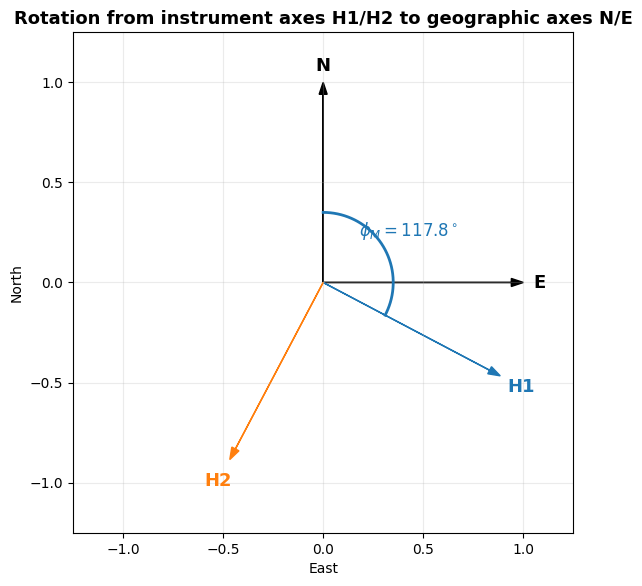

In [15]:
# @title
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt


def wrap_360(angle_deg):
    """Return angle in [0, 360)."""
    return angle_deg % 360.0


def wrap_180(angle_deg):
    """Return signed angle in [-180, 180)."""
    return ((angle_deg + 180.0) % 360.0) - 180.0


def parse_bng_average_stdout(log_text):
    """
    Parse the final BNG estimate from bng_average stdout.

    Expected line:
        |    BNG mean, error, data included: 120.0, 6.2, 24
    """
    pattern = (
        r"(?:B\s*-?\s*N\s*-?\s*G|BNG)"
        r"\s+mean,\s*error,\s*data\s+included:\s*"
        r"([+-]?\d+(?:\.\d+)?),\s*"
        r"([+-]?\d+(?:\.\d+)?),\s*"
        r"(\d+)"
    )

    match = re.search(pattern, log_text, flags=re.IGNORECASE)

    if match is None:
        return None

    return {
        "mean_deg": float(match.group(1)),
        "error_deg": float(match.group(2)),
        "n_used": int(match.group(3)),
    }


log_path = Path("bng_average_stdout.log")

if not log_path.exists():
    raise FileNotFoundError("Could not find bng_average_stdout.log. Run bng_average first.")

log = log_path.read_text()
result = parse_bng_average_stdout(log)

if result is None:
    print("Could not parse the final BNG result from bng_average_stdout.log.")
    print("\nLast lines of stdout:")
    print("---------------------")
    print("\n".join(log.splitlines()[-40:]))
    raise ValueError("Final BNG result not found in stdout log.")

phi_mis_360 = wrap_360(result["mean_deg"])
phi_mis_signed = wrap_180(result["mean_deg"])
phi_err = result["error_deg"]
n_used = result["n_used"]

print("Final OrientPy BNG estimate")
print("---------------------------")
print(f"Station:                         {NETWORK}.{STATION}")
print(f"phi_M, 0-360 convention:          {phi_mis_360:.2f} ± {phi_err:.2f}°")
print(f"phi_M, signed convention:         {phi_mis_signed:.2f} ± {phi_err:.2f}°")
print(f"Number of event estimates used:   {n_used}")
print()
print("Interpretation")
print("--------------")
print(f"The H1 axis is oriented {phi_mis_360:.2f}° clockwise from geographic North.")
print(f"The equivalent signed angle is {phi_mis_signed:.2f}°.")


# ----------------------------------------------------------------------------
# Visualize the orientation geometry
# ----------------------------------------------------------------------------
phi_deg = phi_mis_360
phi = np.deg2rad(phi_deg)

# Geographic axes
N_axis = np.array([0.0, 1.0])   # x = East, y = North
E_axis = np.array([1.0, 0.0])

# Instrument axes in geographic coordinates
# H1 points phi degrees clockwise from North
H1_axis = np.array([np.sin(phi), np.cos(phi)])

# H2 = H1 + 90 degrees clockwise
H2_axis = np.array([
    np.sin(phi + np.pi / 2),
    np.cos(phi + np.pi / 2)
])

fig, ax = plt.subplots(figsize=(6.5, 6.5))

# Geographic axes
ax.arrow(
    0, 0,
    E_axis[0], E_axis[1],
    head_width=0.04,
    length_includes_head=True,
    color="black"
)
ax.arrow(
    0, 0,
    N_axis[0], N_axis[1],
    head_width=0.04,
    length_includes_head=True,
    color="black"
)

ax.text(1.08, 0, "E", ha="center", va="center", fontsize=13, fontweight="bold")
ax.text(0, 1.08, "N", ha="center", va="center", fontsize=13, fontweight="bold")

# Instrument axes
ax.arrow(
    0, 0,
    H1_axis[0], H1_axis[1],
    head_width=0.04,
    length_includes_head=True,
    color="tab:blue"
)
ax.arrow(
    0, 0,
    H2_axis[0], H2_axis[1],
    head_width=0.04,
    length_includes_head=True,
    color="tab:orange"
)

ax.text(
    H1_axis[0] * 1.12,
    H1_axis[1] * 1.12,
    "H1",
    color="tab:blue",
    ha="center",
    va="center",
    fontsize=13,
    fontweight="bold"
)

ax.text(
    H2_axis[0] * 1.12,
    H2_axis[1] * 1.12,
    "H2",
    color="tab:orange",
    ha="center",
    va="center",
    fontsize=13,
    fontweight="bold"
)

# Arc for phi_M
theta = np.linspace(0, phi, 200)
arc_r = 0.35
arc_x = arc_r * np.sin(theta)
arc_y = arc_r * np.cos(theta)
ax.plot(arc_x, arc_y, color="tab:blue", linewidth=2)

mid = phi / 2
ax.text(
    0.50 * np.sin(mid),
    0.50 * np.cos(mid),
    rf"$\phi_M = {phi_deg:.1f}^\circ$",
    color="tab:blue",
    fontsize=12,
    ha="center",
    va="center",
)

ax.set_aspect("equal")
ax.set_xlim(-1.25, 1.25)
ax.set_ylim(-1.25, 1.25)
ax.set_xlabel("East")
ax.set_ylabel("North")
ax.set_title(
    "Rotation from instrument axes H1/H2 to geographic axes N/E",
    fontsize=13,
    fontweight="bold"
)
ax.grid(alpha=0.25)

plt.show()

## From raw H1/H2 to corrected N/E and R/T components

After estimating the misorientation angle, we can use it to correct the horizontal components.

The OBS records the horizontal motion in its own instrumental reference frame:

$$
H1(t), \quad H2(t)
$$

However, before correction, we cannot assume that:

$$
H1(t) = N(t), \qquad H2(t) = E(t).
$$

In this notebook, the estimated angle $\phi_M$ is the clockwise azimuth of the `H1` axis from geographic North.  
Assuming:

$$
H2 = H1 + 90^\circ \; \mathrm{clockwise},
$$

we rotate the instrumental components into geographic components using:

$$
N(t) = \cos \phi_M \, H1(t) - \sin \phi_M \, H2(t),
$$

$$
E(t) = \sin \phi_M \, H1(t) + \cos \phi_M \, H2(t).
$$

This does not change the physical ground motion. It only expresses the same horizontal motion in the correct geographic reference frame:

$$
H1/H2 \quad \longrightarrow \quad N/E.
$$

Once we have corrected `N` and `E`, we can rotate them into radial and transverse components using the theoretical back-azimuth of the earthquake:

$$
N/E \quad \longrightarrow \quad R/T.
$$

The full workflow is therefore:

$$
H1/H2
\quad \xrightarrow{\;\phi_M\;}
N/E
\quad \xrightarrow{\;\mathrm{baz}\;}
R/T.
$$

For a teleseismic P wave, the particle motion should be mainly in the vertical-radial plane.  
Therefore, after the orientation correction, the transverse component should contain less P-wave energy.

In the next figure, we check this directly on one accepted teleseismic event.

Selected event
--------------
Folder:       20150507_071023
Origin time:  2015-05-07T07:10:23.020000Z
P arrival:    2015-05-07T07:17:41.635936Z
Magnitude:    7.0
Depth:        30.4 km
Distance:     38.4 deg
Back-azimuth: 318.3 deg
Event phi:    117.42 deg
SNR:          23.94
CC:           0.99
1 - T/R:      0.91
1 - R/Z:      -0.10

Rotation angle used
-------------------
final BNG mean = 117.8° ± 5.5°

Saved figure:
BNG_RESULTS/YH.LOBS3/YH.LOBS3_example_event_raw_vs_rotated.png


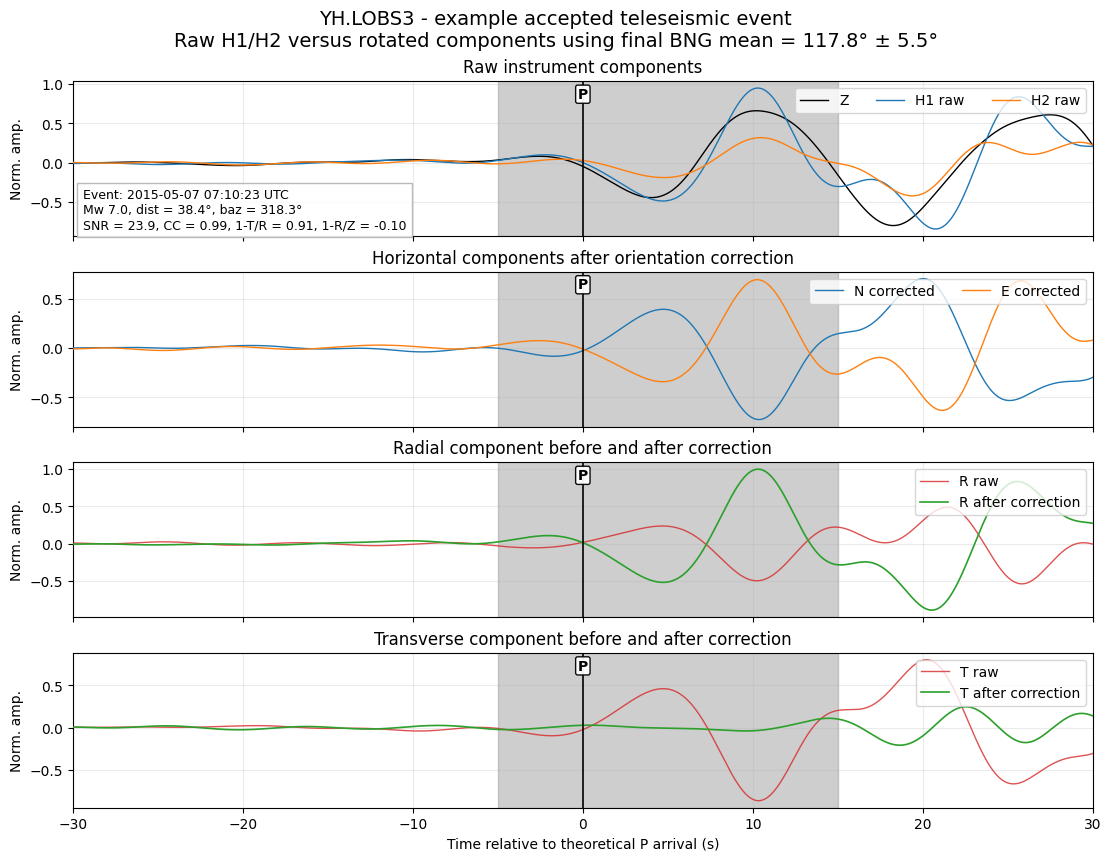

In [16]:
# @title
import re
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from obspy import Stream
from obspy.signal.rotate import rotate_ne_rt


# =============================================================================
# User settings
# =============================================================================
RESULTS_ROOT = Path("BNG_RESULTS")
STKEY = f"{NETWORK}.{STATION}".upper()
STATION_DIR = RESULTS_ROOT / STKEY

# Select which accepted event to plot.
# Accepted events are sorted by decreasing SNR.
SELECT_ACCEPTED_EVENT_INDEX = 0

# Use final station-average BNG angle for the correction.
# If False, use the single-event phi estimate.
USE_FINAL_BNG_MEAN = True

# Plot window around theoretical P arrival.
# Here we show a 60 s window around the P arrival.
PLOT_TMIN = -30.0
PLOT_TMAX = 30.0

# Highlight the measurement window used by bng_calc.
# This uses P_TIMES, e.g. "-5.,15."
HIGHLIGHT_P_WINDOW = True

# Make the P-window shading darker/lighter here.
P_WINDOW_COLOR = "0.55"
P_WINDOW_ALPHA = 0.42

# Normalize traces for visual comparison.
NORMALIZE_TRACES = True

SAVE_FIGURE = True
OUT_FIG = STATION_DIR / f"{STKEY}_example_event_raw_vs_rotated.png"


# =============================================================================
# Helper functions
# =============================================================================
def wrap_360(angle_deg):
    """Return angle in [0, 360)."""
    return float(angle_deg % 360.0)


def wrap_180(angle_deg):
    """Return signed angle in [-180, 180)."""
    return float(((angle_deg + 180.0) % 360.0) - 180.0)


def parse_p_times(p_times_string):
    """Parse OrientPy P_TIMES string, e.g. '-5.,15.'."""
    vals = [float(v) for v in p_times_string.split(",")]
    vals = sorted(vals)
    if len(vals) != 2:
        raise ValueError("P_TIMES must contain two comma-separated values.")
    return vals[0], vals[1]


def parse_bng_average_stdout(log_text):
    """
    Parse lines like:
        |    BNG mean, error, data included: 120.0, 6.2, 24
    """
    pattern = (
        r"(?:B\s*-?\s*N\s*-?\s*G|BNG)"
        r"\s+mean,\s*error,\s*data\s+included:\s*"
        r"([+-]?\d+(?:\.\d+)?),\s*"
        r"([+-]?\d+(?:\.\d+)?),\s*"
        r"(\d+)"
    )

    match = re.search(pattern, log_text, flags=re.IGNORECASE)

    if match is None:
        return None

    return {
        "mean_deg": float(match.group(1)),
        "error_deg": float(match.group(2)),
        "n_used": int(match.group(3)),
    }


def read_final_bng_result():
    """
    Read final BNG estimate from bng_average_stdout.log.
    Fall back to BNG_results.csv if needed.
    """
    log_path = Path("bng_average_stdout.log")

    if log_path.exists():
        parsed = parse_bng_average_stdout(log_path.read_text())
        if parsed is not None:
            return parsed

    summary_csv = STATION_DIR / f"{STKEY}.BNG_results.csv"

    if summary_csv.exists():
        tmp = pd.read_csv(summary_csv)
        tmp.columns = [c.strip() for c in tmp.columns]

        if {"phi mean", "phi error", "#data"}.issubset(tmp.columns):
            row = tmp.iloc[-1]
            return {
                "mean_deg": float(row["phi mean"]),
                "error_deg": float(row["phi error"]),
                "n_used": int(row["#data"]),
            }

    return None


def extract_stream(raw_obj):
    """
    Extract an ObsPy Stream from Raw_data.pkl.
    """
    if isinstance(raw_obj, Stream):
        return raw_obj.copy()

    if isinstance(raw_obj, dict):
        for key in ["st", "stream", "data", "waveforms"]:
            if key in raw_obj and isinstance(raw_obj[key], Stream):
                return raw_obj[key].copy()

    for attr in ["st", "stream", "data", "waveforms"]:
        if hasattr(raw_obj, attr):
            obj = getattr(raw_obj, attr)
            if isinstance(obj, Stream):
                return obj.copy()

    raise TypeError("Could not extract an ObsPy Stream from Raw_data.pkl.")


def get_trace_by_component(stream, component_suffix):
    """
    Return the first trace whose channel ends with component_suffix.
    Example: component_suffix='1' finds HH1.
    """
    matches = [
        tr for tr in stream
        if tr.stats.channel.upper().endswith(component_suffix.upper())
    ]

    if len(matches) == 0:
        available = [tr.stats.channel for tr in stream]
        raise ValueError(
            f"Could not find component '{component_suffix}'. "
            f"Available channels: {available}"
        )

    return matches[0]


def horizontal_to_ne(h1, h2, phi_deg):
    """
    Convert instrument horizontals H1/H2 to geographic N/E.

    Convention:
        phi_deg = clockwise angle from geographic North to H1.
        H2 = H1 + 90 degrees clockwise.

    Forward relation:
        H1 =  cos(phi) * N + sin(phi) * E
        H2 = -sin(phi) * N + cos(phi) * E

    Inverse relation:
        N =  cos(phi) * H1 - sin(phi) * H2
        E =  sin(phi) * H1 + cos(phi) * H2
    """
    phi = np.deg2rad(phi_deg)

    n = np.cos(phi) * h1 - np.sin(phi) * h2
    e = np.sin(phi) * h1 + np.cos(phi) * h2

    return n, e


def normalize_group(*arrays):
    """
    Normalize all arrays by the maximum absolute amplitude among them.
    """
    max_amp = np.nanmax([np.nanmax(np.abs(a)) for a in arrays])

    if not np.isfinite(max_amp) or max_amp == 0:
        return arrays

    return tuple(a / max_amp for a in arrays)


def add_p_pick_and_window(ax, pwin_start, pwin_end):
    """
    Add theoretical P pick, P label, and highlighted measurement window.
    """
    if HIGHLIGHT_P_WINDOW:
        ax.axvspan(
            pwin_start,
            pwin_end,
            color=P_WINDOW_COLOR,
            alpha=P_WINDOW_ALPHA,
            zorder=0,
        )

    ax.axvline(
        0.0,
        color="black",
        linestyle="-",
        linewidth=1.25,
        alpha=0.95,
        zorder=5,
    )

    ax.text(
        0.0,
        0.96,
        "P",
        transform=ax.get_xaxis_transform(),
        ha="center",
        va="top",
        fontsize=10,
        fontweight="bold",
        bbox=dict(
            facecolor="white",
            edgecolor="black",
            boxstyle="round,pad=0.15",
            alpha=0.95,
        ),
        zorder=10,
    )


# =============================================================================
# Load event-level metadata and select one accepted event
# =============================================================================
if not STATION_DIR.exists():
    raise FileNotFoundError(f"Station result directory not found:\n{STATION_DIR}")

meta_files = sorted(STATION_DIR.glob("*/Meta_data.pkl"))

if len(meta_files) == 0:
    raise FileNotFoundError(
        f"No Meta_data.pkl files found in:\n{STATION_DIR}\n"
        "Run bng_calc first."
    )

rows = []

for meta_file in meta_files:
    raw_file = meta_file.parent / "Raw_data.pkl"

    if not raw_file.exists():
        continue

    with open(meta_file, "rb") as f:
        meta = pickle.load(f)

    rows.append({
        "event_folder": meta_file.parent.name,
        "meta_file": meta_file,
        "raw_file": raw_file,
        "origin_time": meta.time,
        "P_arrival_time": meta.time + meta.ttime,
        "phi": float(meta.phi),
        "SNR": float(meta.snr),
        "CC": abs(float(meta.cc)),
        "TR": float(meta.TR),       # OrientPy quantity: 1 - T/R
        "RZ": float(meta.RZ),       # OrientPy quantity: 1 - R/Z
        "baz": float(meta.baz),
        "az": float(meta.az),
        "dist_deg": float(meta.gac),
        "depth_km": float(meta.dep),
        "magnitude": float(meta.mag),
    })

events = pd.DataFrame(rows)

if len(events) == 0:
    raise RuntimeError("No event with both Meta_data.pkl and Raw_data.pkl was found.")

# Same QC logic used in bng_average
events["accepted"] = (
    (events["SNR"] > SNR_THRESHOLD) &
    (events["CC"]  > CC_THRESHOLD) &
    (events["TR"]  > TR_THRESHOLD) &
    (events["RZ"]  > RZ_THRESHOLD)
)

accepted_events = (
    events[events["accepted"]]
    .sort_values("SNR", ascending=False)
    .reset_index(drop=True)
)

if len(accepted_events) == 0:
    raise RuntimeError(
        "No accepted events found with the current QC thresholds. "
        "Relax SNR/CC/TR/RZ thresholds or inspect the bng_average result."
    )

if SELECT_ACCEPTED_EVENT_INDEX >= len(accepted_events):
    raise IndexError(
        f"SELECT_ACCEPTED_EVENT_INDEX={SELECT_ACCEPTED_EVENT_INDEX}, "
        f"but only {len(accepted_events)} accepted events are available."
    )

selected = accepted_events.iloc[SELECT_ACCEPTED_EVENT_INDEX]

print("Selected event")
print("--------------")
print(f"Folder:       {selected['event_folder']}")
print(f"Origin time:  {selected['origin_time']}")
print(f"P arrival:    {selected['P_arrival_time']}")
print(f"Magnitude:    {selected['magnitude']:.1f}")
print(f"Depth:        {selected['depth_km']:.1f} km")
print(f"Distance:     {selected['dist_deg']:.1f} deg")
print(f"Back-azimuth: {selected['baz']:.1f} deg")
print(f"Event phi:    {selected['phi']:.2f} deg")
print(f"SNR:          {selected['SNR']:.2f}")
print(f"CC:           {selected['CC']:.2f}")
print(f"1 - T/R:      {selected['TR']:.2f}")
print(f"1 - R/Z:      {selected['RZ']:.2f}")


# =============================================================================
# Choose angle used for rotation
# =============================================================================
final_result = read_final_bng_result()

if USE_FINAL_BNG_MEAN and final_result is not None:
    phi_rotation = wrap_360(final_result["mean_deg"])
    phi_rotation_label = (
        f"final BNG mean = {phi_rotation:.1f}° ± {final_result['error_deg']:.1f}°"
    )
else:
    phi_rotation = wrap_360(selected["phi"])
    phi_rotation_label = f"single-event phi = {phi_rotation:.1f}°"

print()
print("Rotation angle used")
print("-------------------")
print(phi_rotation_label)


# =============================================================================
# Load, preprocess and trim waveform
# =============================================================================
with open(selected["raw_file"], "rb") as f:
    raw_obj = pickle.load(f)

st = extract_stream(raw_obj)

# Basic preprocessing for visualization.
# Use the same bandpass used in bng_calc, if available.
st.detrend("demean")
st.detrend("linear")
st.taper(max_percentage=0.05)

if BANDPASS is not None:
    fmin, fmax = [float(v) for v in BANDPASS.split(",")]
    st.filter(
        "bandpass",
        freqmin=fmin,
        freqmax=fmax,
        corners=2,
        zerophase=True,
    )

p_arrival = selected["P_arrival_time"]
plot_start = p_arrival + PLOT_TMIN
plot_end = p_arrival + PLOT_TMAX

st.trim(plot_start, plot_end, pad=False)

tr_z = get_trace_by_component(st, ZCOMP)
tr_h1 = get_trace_by_component(st, "1")
tr_h2 = get_trace_by_component(st, "2")

# Force common time support
common_start = max(tr_z.stats.starttime, tr_h1.stats.starttime, tr_h2.stats.starttime)
common_end = min(tr_z.stats.endtime, tr_h1.stats.endtime, tr_h2.stats.endtime)

tr_z = tr_z.copy().trim(common_start, common_end, pad=False)
tr_h1 = tr_h1.copy().trim(common_start, common_end, pad=False)
tr_h2 = tr_h2.copy().trim(common_start, common_end, pad=False)

npts = min(tr_z.stats.npts, tr_h1.stats.npts, tr_h2.stats.npts)

z = tr_z.data[:npts].astype(float)
h1 = tr_h1.data[:npts].astype(float)
h2 = tr_h2.data[:npts].astype(float)

t = tr_z.times()[:npts]
t = t + (tr_z.stats.starttime - p_arrival)

# Correct H1/H2 to geographic N/E
n_corr, e_corr = horizontal_to_ne(h1, h2, phi_rotation)

# For comparison:
# uncorrected assumption: H1 = N, H2 = E
r_uncorr, t_uncorr = rotate_ne_rt(h1, h2, selected["baz"])

# corrected geographic N/E rotated to radial/transverse
r_corr, t_corr = rotate_ne_rt(n_corr, e_corr, selected["baz"])

if NORMALIZE_TRACES:
    z, h1, h2, n_corr, e_corr, r_uncorr, t_uncorr, r_corr, t_corr = normalize_group(
        z, h1, h2, n_corr, e_corr, r_uncorr, t_uncorr, r_corr, t_corr
    )


# =============================================================================
# Plot
# =============================================================================
pwin_start, pwin_end = parse_p_times(P_TIMES)

fig, axes = plt.subplots(
    4,
    1,
    figsize=(11, 8.5),
    sharex=True,
    constrained_layout=True,
)

fig.suptitle(
    f"{STKEY} - example accepted teleseismic event\n"
    f"Raw H1/H2 versus rotated components using {phi_rotation_label}",
    fontsize=14,
)

# -------------------------------------------------------------------------
# Panel 1: vertical and raw instrument horizontals
# -------------------------------------------------------------------------
axes[0].plot(t, z, color="black", linewidth=1.0, label="Z", zorder=3)
axes[0].plot(t, h1, color="tab:blue", linewidth=1.0, label="H1 raw", zorder=3)
axes[0].plot(t, h2, color="tab:orange", linewidth=1.0, label="H2 raw", zorder=3)
axes[0].set_ylabel("Norm. amp." if NORMALIZE_TRACES else "Amplitude")
axes[0].set_title("Raw instrument components")
axes[0].legend(loc="upper right", ncol=3, frameon=True)
axes[0].grid(alpha=0.25)

# -------------------------------------------------------------------------
# Panel 2: corrected geographic components
# -------------------------------------------------------------------------
axes[1].plot(t, n_corr, color="tab:blue", linewidth=1.0, label="N corrected", zorder=3)
axes[1].plot(t, e_corr, color="tab:orange", linewidth=1.0, label="E corrected", zorder=3)
axes[1].set_ylabel("Norm. amp." if NORMALIZE_TRACES else "Amplitude")
axes[1].set_title("Horizontal components after orientation correction")
axes[1].legend(loc="upper right", ncol=2, frameon=True)
axes[1].grid(alpha=0.25)

# -------------------------------------------------------------------------
# Panel 3: radial component before/after correction
# -------------------------------------------------------------------------
axes[2].plot(
    t,
    r_uncorr,
    color="tab:red",
    linewidth=1.0,
    alpha=0.8,
    label="R raw",
    zorder=3,
)
axes[2].plot(
    t,
    r_corr,
    color="tab:green",
    linewidth=1.2,
    label="R after correction",
    zorder=4,
)
axes[2].set_ylabel("Norm. amp." if NORMALIZE_TRACES else "Amplitude")
axes[2].set_title("Radial component before and after correction")
axes[2].legend(loc="upper right", frameon=True)
axes[2].grid(alpha=0.25)

# -------------------------------------------------------------------------
# Panel 4: transverse component before/after correction
# -------------------------------------------------------------------------
axes[3].plot(
    t,
    t_uncorr,
    color="tab:red",
    linewidth=1.0,
    alpha=0.8,
    label="T raw",
    zorder=3,
)
axes[3].plot(
    t,
    t_corr,
    color="tab:green",
    linewidth=1.2,
    label="T after correction",
    zorder=4,
)
axes[3].set_ylabel("Norm. amp." if NORMALIZE_TRACES else "Amplitude")
axes[3].set_xlabel("Time relative to theoretical P arrival (s)")
axes[3].set_title("Transverse component before and after correction")
axes[3].legend(loc="upper right", frameon=True)
axes[3].grid(alpha=0.25)

# -------------------------------------------------------------------------
# Mark P arrival and measurement window
# -------------------------------------------------------------------------
for ax in axes:
    add_p_pick_and_window(ax, pwin_start, pwin_end)

# Annotation
info_text = (
    f"Event: {selected['origin_time'].strftime('%Y-%m-%d %H:%M:%S')} UTC\n"
    f"Mw {selected['magnitude']:.1f}, dist = {selected['dist_deg']:.1f}°, "
    f"baz = {selected['baz']:.1f}°\n"
    f"SNR = {selected['SNR']:.1f}, CC = {selected['CC']:.2f}, "
    f"1-T/R = {selected['TR']:.2f}, 1-R/Z = {selected['RZ']:.2f}"
)

axes[0].text(
    0.01,
    0.03,
    info_text,
    transform=axes[0].transAxes,
    ha="left",
    va="bottom",
    fontsize=9,
    bbox=dict(facecolor="white", edgecolor="0.7", alpha=0.9),
)

axes[3].set_xlim(PLOT_TMIN, PLOT_TMAX)

if SAVE_FIGURE:
    fig.savefig(OUT_FIG, dpi=200, bbox_inches="tight")
    print(f"\nSaved figure:\n{OUT_FIG}")

plt.show()

<p align="center">
  <img src="https://raw.githubusercontent.com/SalvatoreDAmicoResearch/colab_Brest/4cba0d8869784996762ef5e1f0fefa9f2b0ec30a/finale.jpeg" width="700">
</p>



## References and useful links

- OrientPy documentation: https://nfsi-canada.github.io/OrientPy/
- OrientPy GitHub repository: https://github.com/nfsi-canada/orientpy
- StDb: https://github.com/schaefferaj/stdb
- ObsPy FDSN client: https://docs.obspy.org/packages/obspy.clients.fdsn.html
Audet, P. (2020). OrientPy: Seismic station orientation tools (Version v0.0.1) [Computer software]. Zenodo. https://doi.org/10.5281/zenodo.3905404

Braunmiller, J., Nabelek, J., & Ghods, A. (2020). Sensor orientation of Iranian broadband seismic stations from P-wave particle motion. Seismological Research Letters, 91(3), 1660–1671. https://doi.org/10.1785/0220200019

D’Amico, S., Giuntini, A., Simeone, F., De Caro, M., Embriaco, D., Bagiacchi, P., Giacomozzi, E., & Marinaro, G. (2025). Application of multiple approaches to estimate the misorientation angle of an ocean-bottom seismometer using body and surface waves: The case study of the Western Ionian Sea. ResearchGate. https://doi.org/10.13140/RG.2.2.34187.35366

Doran, A. K., & Laske, G. (2017). Ocean-bottom seismometer instrument orientations via automated Rayleigh-wave arrival-angle measurements. Bulletin of the Seismological Society of America, 107(2), 691–708. https://doi.org/10.1785/0120160165

Kennett, B. L. N., & Engdahl, E. R. (1991). Traveltimes for global earthquake location and phase identification. Geophysical Journal International, 105(2), 429–465. https://doi.org/10.1111/j.1365-246X.1991.tb06724.x

Niu, F., & Li, J. (2011). Component azimuths of the CEArray stations estimated from P-wave particle motion. Earthquake Science, 24, 3–13. https://doi.org/10.1007/s11589-011-0764-8

Scholz, J.-R., Barruol, G., Fontaine, F. R., Sigloch, K., Crawford, W. C., & Deen, M. (2017). Orienting ocean-bottom seismometers from P-wave and Rayleigh wave polarisations. Geophysical Journal International, 208(3), 1277–1289. https://doi.org/10.1093/gji/ggw426

Seo, M.-S., Son, Y. O., Kim, Y., Kang, T.-S., Rhie, J., Kim, K.-H., & Ree, J.-H. (2022). Measurement of seismometer misorientation based on P-wave polarization: Application to dense temporary broadband seismic array in the epicentral region of the 2016 Gyeongju earthquake, South Korea. Geosciences Journal, 26, 385–397. https://doi.org/10.1007/s12303-021-0041-3

Son, Y. O., Seo, M.-S., & Kim, Y. (2022). Measurement of seismometer misorientation based on P-wave polarization: Application to permanent seismic network in South Korea. Geosciences Journal, 26, 235–247. https://doi.org/10.1007/s12303-021-0031-5

Stachnik, J. C., Sheehan, A. F., Zietlow, D. W., Yang, Z., Collins, J., & Ferris, A. (2012). Determination of New Zealand ocean bottom seismometer orientation via Rayleigh-wave polarization. Seismological Research Letters, 83(4), 704–713. https://doi.org/10.1785/0220110128